
# WILDS CAMELYON17 preprocessing — PatchCamelyon mirror

This notebook is the **CAMELYON17 (WILDS)** counterpart of the PatchCam workflow in **`notebooks/stain_reference_selection.ipynb`** plus the **`scripts/preprocess_pcam_to_h5.py`** CLI step and the QA pattern from **`notebooks/check_normalization_results.ipynb`**.

| PatchCamelyon | WILDS CAMELYON17 (this notebook) |
|---------------|-----------------------------------|
| Train patches via `keras_pcam.dataset.pcam.load_data` → `train_x[i]` | Train patches via `train_x.h5` (`h5py`, dataset `x`) |
| Stain ref for **PCam-aligned** preprocess | **`stain_reference.json`** + Macenko fit from PCam `train_x.h5` (default in `preprocess_histopath_h5.py --layout wilds`) |
| Optional exploration record (§10) | **`stain_reference_camelyon17.json`** |
| Raw layout `pcam_data/training|val|test/*.h5` | Flat folder `train_x/y.h5`, `valid_x/y.h5`, `test_x/y.h5` from `prepare_wilds_camelyon17_h5.py` |
| Preprocess → `python scripts/preprocess_pcam_to_h5.py` | Same script **+ `--layout wilds`** and `--data-dir` = folder with the six H5 files |

**Pipeline:** quality scoring / reference picking (below, same logic as PCam notebook §1–4) → **Macenko/Reinhard exploratory plots** (same as PCam; informative if you use `--stain-mode adaptive`) → save reference JSON → **`preprocess_pcam_to_h5.py`** → optional **before/after QA** on test.

**Defaults:** preprocessing CLI defaults to **`--stain-mode macenko`** (classical Macenko only). Use **`adaptive`** for Macenko/Reinhard routing + purple-tail pass (same optional behavior as PCam).



## Prerequisites

- WILDS CAMELYON17 extracted under `data/wilds/camelyon17_v1.0/` (PNGs + `metadata.csv`).
- Six raw H5 files in `WILDS_H5_DIR` (see below). Build them with §1 if needed.
- Same Python deps as PCam preprocessing: `h5py`, `numpy`, `tqdm`, **`staintools`** (+ **`spams`** / `spams-bin` on Windows) for reference-validation cells below.


In [1]:
import os
import sys
from pathlib import Path

def resolve_project_root():
    """Same idea as `notebooks/show_stain_reference_patch.ipynb`: cwd may be repo root or notebooks/."""
    for base in (Path(".").resolve(), Path("..").resolve()):
        if (base / "scripts" / "preprocess_pcam_to_h5.py").is_file():
            return base
    raise FileNotFoundError(
        "Run from GP_ECG repo root or notebooks/ (need scripts/preprocess_pcam_to_h5.py)."
    )

PROJECT_ROOT = str(resolve_project_root())
sys.path.insert(0, PROJECT_ROOT)

WILDS_H5_DIR = os.path.join(PROJECT_ROOT, "data", "wilds", "camelyon17_h5_full_oodval")
PREPROCESSED_SUBDIR = "preprocessed_macenko_benchmark_style"
REF_CONFIG = os.path.join(PROJECT_ROOT, "experiments", "stain_reference", "stain_reference_camelyon17.json")
TRAIN_X_PATH = os.path.join(WILDS_H5_DIR, "train_x.h5")
PREPROC_DIR = os.path.join(WILDS_H5_DIR, PREPROCESSED_SUBDIR)

print("PROJECT_ROOT", PROJECT_ROOT)
print("WILDS_H5_DIR", WILDS_H5_DIR)
print("PREPROC_DIR", PREPROC_DIR)

_need = [
    os.path.join(WILDS_H5_DIR, "train_x.h5"),
    os.path.join(WILDS_H5_DIR, "train_y.h5"),
    os.path.join(WILDS_H5_DIR, "valid_x.h5"),
    os.path.join(WILDS_H5_DIR, "valid_y.h5"),
    os.path.join(WILDS_H5_DIR, "test_x.h5"),
    os.path.join(WILDS_H5_DIR, "test_y.h5"),
]
for p in _need:
    print("OK" if os.path.isfile(p) else "MISSING", p)


PROJECT_ROOT C:\GP_ECG
WILDS_H5_DIR C:\GP_ECG\data\wilds\camelyon17_h5_full_oodval
PREPROC_DIR C:\GP_ECG\data\wilds\camelyon17_h5_full_oodval\preprocessed_macenko_benchmark_style
OK C:\GP_ECG\data\wilds\camelyon17_h5_full_oodval\train_x.h5
OK C:\GP_ECG\data\wilds\camelyon17_h5_full_oodval\train_y.h5
OK C:\GP_ECG\data\wilds\camelyon17_h5_full_oodval\valid_x.h5
OK C:\GP_ECG\data\wilds\camelyon17_h5_full_oodval\valid_y.h5
OK C:\GP_ECG\data\wilds\camelyon17_h5_full_oodval\test_x.h5
OK C:\GP_ECG\data\wilds\camelyon17_h5_full_oodval\test_y.h5



## 1. (Optional) Build raw `[0,1]` float32 H5 from WILDS PNGs

Same role as having PCam HDF5 already downloaded: produce **`train_*`, `valid_*`, `test_*`** consumed by the preprocessor.

```bash
python scripts/camelyon17/prepare_wilds_camelyon17_h5.py \
  --dataset-dir data/wilds/camelyon17_v1.0 \
  --out-dir data/wilds/camelyon17_h5_full_oodval \
  --valid-source val \
  --write-aux-splits
```

Use `--valid-source id_val` if `valid_*` should be **in-domain** validation instead of **OOD** (`val`).


In [2]:
# Uncomment to run conversion from the notebook.
# import subprocess
# subprocess.run([
#     sys.executable,
#     os.path.join(PROJECT_ROOT, "scripts", "camelyon17", "prepare_wilds_camelyon17_h5.py"),
#     "--dataset-dir", os.path.join(PROJECT_ROOT, "data", "wilds", "camelyon17_v1.0"),
#     "--out-dir", WILDS_H5_DIR,
#     "--valid-source", "val",
#     "--write-aux-splits",
# ], cwd=PROJECT_ROOT, check=True)
pass



## 2. Load CAM17 train metadata (mirror PCam "Loaded train:" cell)

PatchCam opens the full train tensor via `load_data`; here we only need **`train_x.h5`** shape (indices match `reference_train_index`).


In [3]:
import h5py

if not os.path.isfile(TRAIN_X_PATH):
    raise FileNotFoundError(TRAIN_X_PATH)

with h5py.File(TRAIN_X_PATH, "r") as f:
    n_train = int(f["x"].shape[0])
print("Loaded train patches:", n_train, "from", TRAIN_X_PATH)


Loaded train patches: 302436 from C:\GP_ECG\data\wilds\camelyon17_h5_full_oodval\train_x.h5



## 3. Quality helpers — **same definitions as `stain_reference_selection.ipynb` §1**

Candidate patches require **tissue % final ≥ REFERENCE_MIN_TISSUE**, exclude solid-color and high-black (same thresholds as PCam notebook).


In [4]:
import numpy as np
from scipy.ndimage import uniform_filter

def otsu_threshold_01(gray):
    flat = np.asarray(gray).ravel().astype(np.float64)
    hist, _ = np.histogram(flat, bins=256, range=(0, 1))
    bin_centers = (np.arange(256) + 0.5) / 256.0
    total = hist.sum()
    if total == 0:
        return 0.5
    p = hist / total
    sigma_b_sq_max, best_t = -1.0, 0.5
    for t in range(1, 255):
        w0, w1 = p[:t].sum(), p[t:].sum()
        if w0 == 0 or w1 == 0:
            continue
        mu0 = (p[:t] * bin_centers[:t]).sum() / w0
        mu1 = (p[t:] * bin_centers[t:]).sum() / w1
        sigma_b_sq = w0 * w1 * (mu0 - mu1) ** 2
        if sigma_b_sq > sigma_b_sq_max:
            sigma_b_sq_max, best_t = sigma_b_sq, bin_centers[t]
    return best_t

def saturation_from_rgb(rgb):
    mx, mn = rgb.max(axis=2), rgb.min(axis=2)
    return np.where(mx > 1e-8, (mx - mn) / mx, 0.0)

def local_variance_map(gray, win=11):
    m = uniform_filter(gray.astype(np.float64), size=win, mode="nearest")
    m2 = uniform_filter((gray.astype(np.float64)) ** 2, size=win, mode="nearest")
    return m2 - m**2

def tissue_pct_otsu_normalized(gray):
    p5, p95 = np.percentile(gray, 5), np.percentile(gray, 95)
    span = max(p95 - p5, 1e-8)
    g = np.clip((gray - p5) / span, 0, 1)
    t = otsu_threshold_01(g)
    return float(np.sum(g < t) / g.size)

SAT_THRESHOLD = 0.12
VAR_THRESHOLD = 0.003
EDGE_LO, EDGE_HI = 0.12, 0.45
SOLID_COLOR_STD_THRESHOLD = 0.04
HIGH_BLACK_THRESHOLD = 0.5
REFERENCE_MIN_TISSUE = 0.5
LOCAL_VAR_WIN = 11

print(
    "Reference candidates: tissue % final >=",
    REFERENCE_MIN_TISSUE,
    "| constants aligned with stain_reference_selection.ipynb",
)


Reference candidates: tissue % final >= 0.5 | constants aligned with stain_reference_selection.ipynb



## 4. Sample patches — **mirror PCam notebook loop**

Reads random indices from **`train_x.h5`**; identical feature rows (`blue_dom_pct`, tissue chain).


In [5]:
def read_train_patch_01(idx):
    with h5py.File(TRAIN_X_PATH, "r") as f:
        patch = np.asarray(f["x"][int(idx)], dtype=np.float64)
    if patch.max() > 1.0:
        patch = patch / 255.0
    return np.clip(patch, 0, 1)

n_sample = min(30000, n_train)
np.random.seed(42)
indices = np.random.choice(n_train, size=n_sample, replace=False)

rows = []
for i in indices:
    patch = read_train_patch_01(i)
    gray = patch.mean(axis=2)
    n_px = gray.size
    n_elems = patch.size
    ratio_black = float(np.sum(patch <= 0.1) / n_elems)
    gray_std = float(np.std(gray))
    sat = saturation_from_rgb(patch)
    tissue_pct_sat = float(np.sum(sat > SAT_THRESHOLD) / n_px)
    var_map = local_variance_map(gray, win=LOCAL_VAR_WIN)
    tissue_pct_combined = float(np.sum((sat > SAT_THRESHOLD) | (var_map > VAR_THRESHOLD)) / n_px)
    if EDGE_LO < tissue_pct_combined < EDGE_HI:
        otsu_norm = tissue_pct_otsu_normalized(gray)
        tissue_pct_final = max(tissue_pct_combined, otsu_norm)
    else:
        tissue_pct_final = tissue_pct_combined
    mean_rgb = patch.reshape(-1, 3).mean(axis=0)
    solid_color = 1 if gray_std < SOLID_COLOR_STD_THRESHOLD else 0
    blue_dom_pct = float((patch[:, :, 2] > patch[:, :, 0]).mean())
    rows.append(
        (
            int(i),
            ratio_black,
            gray_std,
            tissue_pct_final,
            solid_color,
            mean_rgb[0],
            mean_rgb[1],
            mean_rgb[2],
            blue_dom_pct,
        )
    )

data = np.array(rows, dtype=np.float64)
idx_col = 0
b_col, std_col, tissue_col, solid_col = 1, 2, 3, 4
r_col, g_col, b_mean_col = 5, 6, 7
blue_dom_col = 8

solid_mask = data[:, solid_col] == 1
high_black_mask = data[:, b_col] >= HIGH_BLACK_THRESHOLD
high_tissue_mask = data[:, tissue_col] >= REFERENCE_MIN_TISSUE
candidate_mask = ~solid_mask & ~high_black_mask & high_tissue_mask
candidates = data[candidate_mask]

print("Sampled", n_sample, "patches")
print(
    "Solid-color:",
    int(solid_mask.sum()),
    "| High black:",
    int(high_black_mask.sum()),
    "| Tissue >=",
    REFERENCE_MIN_TISSUE,
    ":",
    int(high_tissue_mask.sum()),
)
print("Reference candidates:", len(candidates))


C:\Users\tamer\AppData\Local\Temp\ipykernel_4932\828599942.py:26: RuntimeWarning: invalid value encountered in divide
  return np.where(mx > 1e-8, (mx - mn) / mx, 0.0)


Sampled 30000 patches
Solid-color: 39 | High black: 72 | Tissue >= 0.5 : 28719
Reference candidates: 28667



## 5. Pick reference — **mirror PCam weighted median heuristic**

Same weights `[1.0, 1.5, 1.0, 1.5]` on `(tissue, R, G, B)`.


In [6]:
if len(candidates) == 0:
    raise RuntimeError("No reference candidates. Lower REFERENCE_MIN_TISSUE or increase n_sample.")

med_tissue = np.median(candidates[:, tissue_col])
med_r = np.median(candidates[:, r_col])
med_g = np.median(candidates[:, g_col])
med_b = np.median(candidates[:, b_mean_col])
target = np.array([med_tissue, med_r, med_g, med_b])
feats = candidates[:, [tissue_col, r_col, g_col, b_mean_col]]
weights = np.array([1.0, 1.5, 1.0, 1.5])
dists = np.sum(weights * (feats - target) ** 2, axis=1)
best_idx_in_candidates = int(np.argmin(dists))
ref_train_idx = int(candidates[best_idx_in_candidates, idx_col])

print(
    "Target (median tissue, R, G, B):",
    round(med_tissue, 3),
    round(med_r, 3),
    round(med_g, 3),
    round(med_b, 3),
)
print(
    "Chosen reference train index",
    ref_train_idx,
    "| tissue % =",
    round(float(candidates[best_idx_in_candidates, tissue_col]), 3),
)


Target (median tissue, R, G, B): 0.999 0.758 0.591 0.749
Chosen reference train index 268886 | tissue % = 1.0


## 6. Show reference patch — mirror PCam display


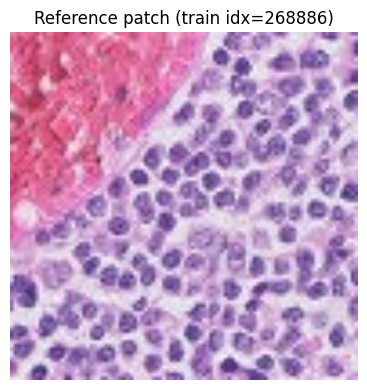

In [7]:
import matplotlib.pyplot as plt

ref_patch = read_train_patch_01(ref_train_idx)
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(ref_patch, interpolation="bilinear")
ax.set_title("Reference patch (train idx=" + str(ref_train_idx) + ")")
ax.axis("off")
plt.tight_layout()
plt.show()



## 7. Fit Macenko — mirror PCam notebook §3


In [8]:
try:
    from staintools import StainNormalizer

    STAINTOOLS_AVAILABLE = True
except ImportError as e:
    STAINTOOLS_AVAILABLE = False
    print("StainTools import failed:", e)
    print("If No module named spams: pip install spams-bin (Windows); restart kernel.")

normalizer = None
if STAINTOOLS_AVAILABLE:
    ref_uint8 = (np.clip(ref_patch, 0, 1) * 255).astype(np.uint8)
    try:
        from staintools.preprocessing.luminosity_standardizer import LuminosityStandardizer

        ref_uint8 = LuminosityStandardizer.standardize(ref_uint8)
    except Exception as e_std:
        print("Luminosity standardizer skipped:", e_std)
    try:
        normalizer = StainNormalizer(method="macenko")
        normalizer.fit(ref_uint8)
        print("Macenko fitted successfully on reference patch.")
    except Exception as e:
        print("Macenko fit failed:", e)
        normalizer = None


Macenko fitted successfully on reference patch.



## 8. Optional candidate grid — mirror PCam (`contrast_stretch_uint8` demo)


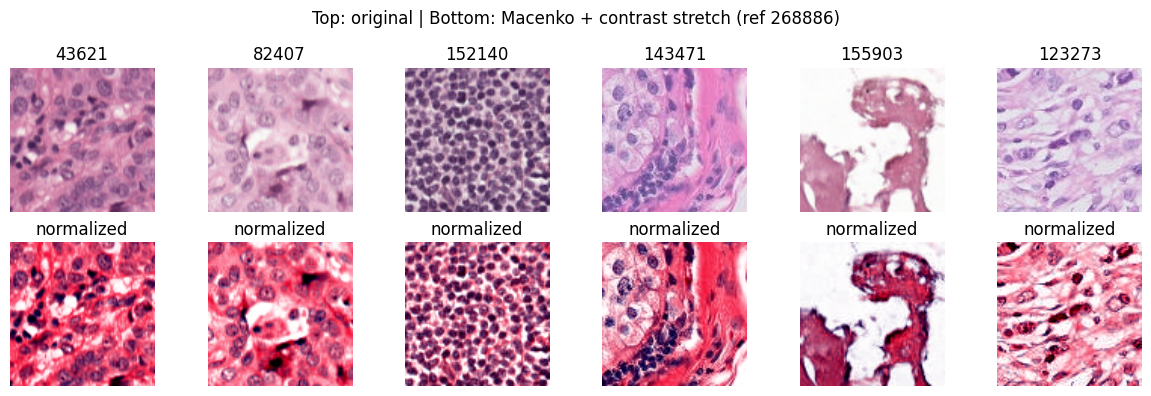

In [9]:
def contrast_stretch_uint8(img, p_low=2, p_high=98):
    lo, hi = np.percentile(img, (p_low, p_high))
    if hi <= lo:
        return img
    out = (np.clip(img.astype(np.float32), lo, hi) - lo) / (hi - lo) * 255
    return out.astype(np.uint8)

def patch_to_uint8(p):
    if p.max() <= 1.0:
        return (np.clip(p, 0, 1) * 255).astype(np.uint8)
    return np.clip(p, 0, 255).astype(np.uint8)

if normalizer is not None:
    n_show = 6
    other_indices = [
        int(candidates[i, idx_col])
        for i in range(len(candidates))
        if int(candidates[i, idx_col]) != ref_train_idx
    ][:n_show]
    fig, axes = plt.subplots(2, n_show, figsize=(2 * n_show, 4))
    for j, idx in enumerate(other_indices[:n_show]):
        p = patch_to_uint8(read_train_patch_01(idx))
        axes[0, j].imshow(p, interpolation="bilinear")
        axes[0, j].set_title(str(idx))
        axes[0, j].axis("off")
        try:
            try:
                from staintools.preprocessing.luminosity_standardizer import LuminosityStandardizer

                p2 = LuminosityStandardizer.standardize(p.copy())
            except Exception:
                p2 = p
            p_norm = normalizer.transform(p2)
            p_norm = contrast_stretch_uint8(p_norm)
            axes[1, j].imshow(p_norm, interpolation="bilinear")
        except Exception:
            axes[1, j].text(0.5, 0.5, "fail", ha="center", va="center")
        axes[1, j].set_title("normalized")
        axes[1, j].axis("off")
    plt.suptitle("Top: original | Bottom: Macenko + contrast stretch (ref " + str(ref_train_idx) + ")")
    plt.tight_layout()
    plt.show()
else:
    print("Skip grid (Macenko not fitted).")



## 9. Macenko vs Reinhard — mirror PCam notebook §4

Threshold = **25th percentile** of `blue_dom_pct` on the same **`data`** sample. Demo patches: **two lowest blue_dom** rows in this sample (PCam uses fixed indices `154241`, `202357`).


blue_dom_pct threshold (p25): 0.094
Of 30000 sampled patches: 7497 -> Reinhard, 22503 -> Macenko


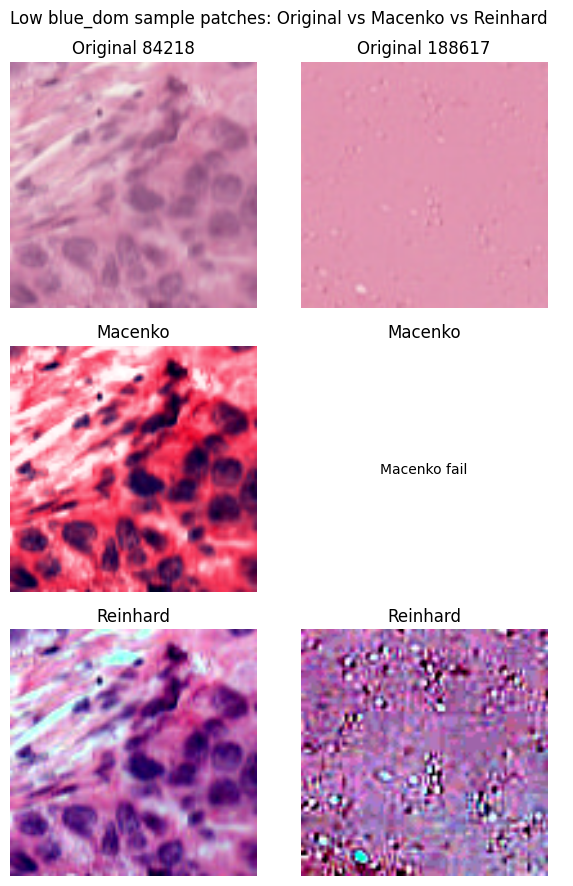

In [10]:
REINHARD_PERCENTILE = 25
blue_dom_threshold = np.percentile(data[:, blue_dom_col], REINHARD_PERCENTILE)
to_reinhard = data[:, blue_dom_col] < blue_dom_threshold
print(
    "blue_dom_pct threshold (p" + str(REINHARD_PERCENTILE) + "):",
    round(float(blue_dom_threshold), 4),
)
print(
    "Of",
    len(data),
    "sampled patches:",
    int(to_reinhard.sum()),
    "-> Reinhard,",
    int(len(data) - to_reinhard.sum()),
    "-> Macenko",
)

ref_uint8_demo = patch_to_uint8(ref_patch)
try:
    from staintools import ReinhardColorNormalizer

    reinhard_norm = ReinhardColorNormalizer()
    reinhard_norm.fit(ref_uint8_demo)
except Exception as e:
    reinhard_norm = None
    print("Reinhard fit failed:", e)

order = np.argsort(data[:, blue_dom_col])
bad_idx = [int(data[int(order[0]), idx_col]), int(data[int(order[1]), idx_col])]

if normalizer is None or reinhard_norm is None:
    print("Skip Original/Macenko/Reinhard grid (need both normalizers).")
else:
    fig, axes = plt.subplots(3, 2, figsize=(6, 9))
    for j, idx in enumerate(bad_idx):
        p_uint8 = patch_to_uint8(read_train_patch_01(idx))
        axes[0, j].imshow(p_uint8, interpolation="bilinear")
        axes[0, j].set_title("Original " + str(idx))
        axes[0, j].axis("off")
        try:
            try:
                from staintools.preprocessing.luminosity_standardizer import LuminosityStandardizer

                pm = LuminosityStandardizer.standardize(p_uint8.copy())
            except Exception:
                pm = p_uint8
            p_mac = normalizer.transform(pm)
            axes[1, j].imshow(contrast_stretch_uint8(p_mac), interpolation="bilinear")
        except Exception:
            axes[1, j].text(0.5, 0.5, "Macenko fail", ha="center", va="center")
        axes[1, j].set_title("Macenko")
        axes[1, j].axis("off")
        try:
            pr = reinhard_norm.transform(p_uint8.copy())
            axes[2, j].imshow(contrast_stretch_uint8(pr), interpolation="bilinear")
        except Exception:
            axes[2, j].text(0.5, 0.5, "Reinhard fail", ha="center", va="center")
        axes[2, j].set_title("Reinhard")
        axes[2, j].axis("off")
    plt.suptitle("Low blue_dom sample patches: Original vs Macenko vs Reinhard")
    plt.tight_layout()
    plt.show()



## 10. Save reference JSON — mirror PCam (`stain_reference.json` keys)

Writes **`stain_reference_camelyon17.json`** next to the PCam file under `experiments/stain_reference/`.


In [11]:
import json

out_dir = os.path.join(PROJECT_ROOT, "experiments", "stain_reference")
os.makedirs(out_dir, exist_ok=True)

stain_ref = {
    "reference_train_index": ref_train_idx,
    "REFERENCE_MIN_TISSUE": REFERENCE_MIN_TISSUE,
    "n_candidates": int(len(candidates)),
    "n_sample": int(n_sample),
}
with open(REF_CONFIG, "w", encoding="utf-8") as f:
    json.dump(stain_ref, f, indent=2)
print("Saved", REF_CONFIG)
print(json.dumps(stain_ref, indent=2))


Saved C:\GP_ECG\experiments\stain_reference\stain_reference_camelyon17.json
{
  "reference_train_index": 268886,
  "REFERENCE_MIN_TISSUE": 0.5,
  "n_candidates": 28667,
  "n_sample": 30000
}



## 11. Run `preprocess_pcam_to_h5.py` — mirror PCam CLI

Add **`--layout wilds`**; `--data-dir` is the folder with the six raw H5 files. Default **`--stain-mode`** is **`macenko`** (omit flag). Uncomment **`subprocess.run`** to execute.


In [12]:
import subprocess

prep_script = os.path.join(PROJECT_ROOT, "scripts", "preprocess_pcam_to_h5.py")
cmd = [
    sys.executable,
    prep_script,
    "--layout",
    "wilds",
    "--data-dir",
    WILDS_H5_DIR,
    "--preprocessed-subdir",
    PREPROCESSED_SUBDIR,
    "--ref-config",
    REF_CONFIG,
    # "--stain-mode", "adaptive",
    # "--resume",
]
print(" ".join(cmd))
# subprocess.run(cmd, cwd=PROJECT_ROOT, check=True)


c:\GP_ECG\.venv\Scripts\python.exe C:\GP_ECG\scripts\preprocess_pcam_to_h5.py --layout wilds --data-dir C:\GP_ECG\data\wilds\camelyon17_h5_full_oodval --preprocessed-subdir preprocessed_macenko_benchmark_style --ref-config C:\GP_ECG\experiments\stain_reference\stain_reference_camelyon17.json



## 12. Status (`--status`) — mirror interrupted-run check

```bash
python scripts/preprocess_pcam_to_h5.py --layout wilds --data-dir <WILDS_H5_DIR> --preprocessed-subdir <PREPROCESSED_SUBDIR> --status
```



## 13. QA — mirror `check_normalization_results.ipynb` with correct indexing

Aligns **`manifest["test"]["kept_indices"]`** so **`orig file[idx]`** pairs with **`norm[pos]`**.


In [13]:
import json
import math

orig_test_x_path = os.path.join(WILDS_H5_DIR, "test_x.h5")
norm_test_x_path = os.path.join(PREPROC_DIR, "test_x.h5")
report_path = os.path.join(PREPROC_DIR, "preprocess_report.json")
manifest_path = os.path.join(PREPROC_DIR, "manifest.json")

if not (
    os.path.isfile(norm_test_x_path)
    and os.path.isfile(manifest_path)
    and os.path.isfile(report_path)
):
    print("Skip QA: need preprocessed test_x.h5, manifest.json, preprocess_report.json under PREPROC_DIR.")
else:
    with open(report_path, "r", encoding="utf-8") as f:
        report = json.load(f)
    ref_mean_rgb = np.array(report["config"]["ref_mean_rgb"], dtype=np.float32)
    print("Reference mean RGB (from preprocess_report):", ref_mean_rgb)

    with h5py.File(orig_test_x_path, "r") as f_orig, h5py.File(norm_test_x_path, "r") as f_norm:
        x_orig_full = f_orig["x"]
        x_norm = f_norm["x"][:]

    with open(manifest_path, "r", encoding="utf-8") as f:
        manifest = json.load(f)
    kept_test = np.array(manifest["test"]["kept_indices"], dtype=np.int64)
    assert kept_test.shape[0] == x_norm.shape[0]

    x_orig_kept = np.asarray(x_orig_full[kept_test], dtype=np.float32)
    if x_orig_kept.max() > 1:
        x_orig_01 = np.clip(x_orig_kept / 255.0, 0, 1)
    else:
        x_orig_01 = np.clip(x_orig_kept, 0, 1)

    def mean_rgb_and_pink(x01):
        flat = x01.reshape(-1, 3)
        mean_rgb = flat.mean(axis=0)
        pink_pct = float((x01[..., 0] > x01[..., 2]).mean())
        return mean_rgb, pink_pct

    n_total = x_norm.shape[0]
    rng = np.random.RandomState(42)
    sample_size = min(5000, n_total)
    sample_pos = rng.choice(n_total, size=sample_size, replace=False)

    mean_ref = ref_mean_rgb
    dist_before, dist_after, is_purple_only = [], [], []
    for pos in sample_pos:
        pos = int(pos)
        m_bef, _ = mean_rgb_and_pink(x_orig_01[pos])
        m_aft, pink_aft = mean_rgb_and_pink(x_norm[pos])
        d_bef = float(np.abs(m_bef - mean_ref).sum())
        d_aft = float(np.abs(m_aft - mean_ref).sum())
        dist_before.append(d_bef)
        dist_after.append(d_aft)
        is_purple_only.append((m_aft[0] < 0.2) or (pink_aft < 0.05))

    dist_before = np.array(dist_before)
    dist_after = np.array(dist_after)
    is_purple_only = np.array(is_purple_only)
    delta = dist_after - dist_before
    print("Mean distance before / after (sample):", float(dist_before.mean()), "/", float(dist_after.mean()))
    print("Fraction purple-only after norm (sample):", float(is_purple_only.mean()))

    def show_before_after_positions(positions, title, n_pairs_per_row=2):
        if len(positions) == 0:
            print("No indices:", title)
            return
        positions = np.asarray(positions, dtype=np.int64)
        n = len(positions)
        n_cols = n_pairs_per_row * 2
        n_rows = int(math.ceil(n / n_pairs_per_row))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
        axes = np.atleast_1d(axes).ravel()
        ax_i = 0
        for pos in positions:
            pos = int(pos)
            orig_idx = int(kept_test[pos])
            orig = x_orig_01[pos]
            norm = x_norm[pos]
            axes[ax_i].imshow(orig)
            axes[ax_i].set_title("orig file[" + str(orig_idx) + "]")
            axes[ax_i].axis("off")
            ax_i += 1
            axes[ax_i].imshow(norm)
            axes[ax_i].set_title("norm pos=" + str(pos))
            axes[ax_i].axis("off")
            ax_i += 1
        for j in range(ax_i, len(axes)):
            axes[j].axis("off")
        fig.suptitle(title, fontsize=14)
        plt.tight_layout()
        plt.show()

    k = min(48, sample_size)
    worst_order = np.argsort(delta)[::-1]
    worst_pos = sample_pos[worst_order[:k]]
    show_before_after_positions(worst_pos, "Largest increase in L1 distance to ref mean RGB")

    purple_pos = sample_pos[is_purple_only]
    show_before_after_positions(purple_pos[:k], "Purple-flagged after normalization (sample)")


Skip QA: need preprocessed test_x.h5, manifest.json, preprocess_report.json under PREPROC_DIR.
